In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

### Load the datasets

In [ ]:
ratings_df = pd.read_csv('/content/ratings_clean.csv')
movies_df = pd.read_csv('/content/movies_clean.csv')

### Display the first 5 rows of the `ratings_df` DataFrame

In [ ]:
display(ratings_df.head())

,userId,ratingId,rating,timestamp,tmdbId,title,genres_str,genre_list
0,60644,1,5.0,2018-03-09 23:41:01,862,Toy Story,Animation|Comedy|Family,"['Animation', 'Comedy', 'Family']"
1,60564,1,5.0,2000-08-12 05:18:41,862,Toy Story,Animation|Comedy|Family,"['Animation', 'Comedy', 'Family']"
2,60889,1,4.0,1997-10-11 08:19:05,862,Toy Story,Animation|Comedy|Family,"['Animation', 'Comedy', 'Family']"
3,60049,1,3.0,2007-11-27 20:47:11,862,Toy Story,Animation|Comedy|Family,"['Animation', 'Comedy', 'Family']"
4,60305,1,4.0,2002-11-14 01:55:40,862,Toy Story,Animation|Comedy|Family,"['Animation', 'Comedy', 'Family']"


### Display the first 5 rows of the `movies_df` DataFrame

In [ ]:
display(movies_df.head())

,budget,genres,homepage,tmdbId,keywords,original_language,original_title,overview,popularity,production_companies,...,vote_count,ratingId,genre_list,keyword_list,genres_str,cast,crew,avg_rating,num_ratings,rating_std
0,55000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",NaN,13,"[{""id"": 422, ""name"": ""vietnam veteran""}, {""id""...",en,Forrest Gump,A man with a low IQ has accomplished great thi...,138.133331,"[{""name"": ""Paramount Pictures"", ""id"": 4}]",...,7927,356,"['Comedy', 'Drama', 'Romance']","['vietnam veteran', 'hippie', 'mentally disabl...",Comedy|Drama|Romance,"[{""cast_id"": 7, ""character"": ""Forrest Gump"", ""...","[{""credit_id"": ""52fe420ec3a36847f800076b"", ""de...",4.02,1460,0.92
1,25000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",NaN,278,"[{""id"": 378, ""name"": ""prison""}, {""id"": 417, ""n...",en,The Shawshank Redemption,Framed in the 1940s for the double murder of h...,136.747729,"[{""name"": ""Castle Rock Entertainment"", ""id"": 97}]",...,8205,318,"['Drama', 'Crime']","['prison', 'corruption', 'police brutality', '...",Drama|Crime,"[{""cast_id"": 3, ""character"": ""Andy Dufresne"", ...","[{""credit_id"": ""52fe4231c3a36847f800b153"", ""de...",4.38,1412,0.78
2,8000000,"[{""id"": 53, ""name"": ""Thriller""}, {""id"": 80, ""n...",NaN,680,"[{""id"": 396, ""name"": ""transporter""}, {""id"": 14...",en,Pulp Fiction,"A burger-loving hit man, his philosophical par...",121.463076,"[{""name"": ""Miramax Films"", ""id"": 14}, {""name"":...",...,8428,296,"['Thriller', 'Crime']","['transporter', 'brothel', 'drug dealer', 'box...",Thriller|Crime,"[{""cast_id"": 2, ""character"": ""Vincent Vega"", ""...","[{""credit_id"": ""52fe4269c3a36847f801caa3"", ""de...",4.24,1375,0.94
3,19000000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 18, ""name...",NaN,274,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,The Silence of the Lambs,"FBI trainee, Clarice Starling ventures into a ...",18.174804,"[{""name"": ""Orion Pictures"", ""id"": 41}, {""name""...",...,4443,593,"['Crime', 'Drama', 'Thriller']","['based on novel', 'psychopath', 'horror', 'su...",Crime|Drama|Thriller,"[{""cast_id"": 1, ""character"": ""Clarice Starling...","[{""credit_id"": ""55746f699251413f3a001b82"", ""de...",4.13,1341,0.86
4,63000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 878, ""na...",http://www.warnerbros.com/matrix,603,"[{""id"": 83, ""name"": ""saving the world""}, {""id""...",en,The Matrix,"Set in the 22nd century, The Matrix tells the ...",104.309993,"[{""name"": ""Village Roadshow Pictures"", ""id"": 7...",...,8907,2571,"['Action', 'Science Fiction']","['saving the world', 'artificial intelligence'...",Action|Science Fiction,"[{""cast_id"": 34, ""character"": ""Thomas \""Neo\"" ...","[{""credit_id"": ""5831cc6d92514162d2027340"", ""de...",4.19,1443,0.82


### Data Exploration and Cleaning

This section performs initial data exploration, checking for the shape, data types, missing values, and duplicate entries in both the `ratings_df` and `movies_df` DataFrames. It also includes steps to handle any identified duplicate records to ensure data quality for the recommendation system.

#### `ratings_df` Overview and Cleaning

In [ ]:
# 1. Display the shape of the ratings DataFrame
# The shape (rows, columns) provides a quick overview of the dataset size.
print(f"Shape of ratings_df: {ratings_df.shape}")

# 2. Display information about the DataFrame, including data types and non-null values
# This helps in identifying potential data type issues and non-null counts.
print("\nInformation about ratings_df:")
ratings_df.info()

# 3. Check for missing values in each column
# Missing values can impact model performance and need to be handled appropriately.
print("\nMissing values in ratings_df:")
display(ratings_df.isnull().sum())

# 4. Check for duplicate (userId, ratingId) pairs
# Duplicate ratings for the same user-movie pair indicate potential data entry errors or multiple ratings over time.
# We will handle these by taking the mean rating, assuming the average is a fair representation.
print("\nChecking for duplicate (userId, ratingId) pairs in ratings_df...")
duplicate_ratings_count = ratings_df.duplicated(subset=['userId', 'ratingId']).sum()
print(f"Number of duplicate (userId, ratingId) pairs: {duplicate_ratings_count}")

if duplicate_ratings_count > 0:
    print("Handling duplicate (userId, ratingId) records by taking the mean rating for 'rating'...")
    # Group by userId and ratingId, then aggregate. For 'rating', calculate the mean.
    # For other columns like 'timestamp', 'tmdbId', 'title', 'genres_str', 'genre_list',
    # we assume they are consistent for duplicate (userId, ratingId) entries and take the first occurrence.
    ratings_df = ratings_df.groupby(['userId', 'ratingId']).agg({
        'rating': 'mean',
        'timestamp': 'first',
        'tmdbId': 'first',
        'title': 'first',
        'genres_str': 'first',
        'genre_list': 'first'
    }).reset_index()
    print("Duplicates handled. New shape of ratings_df:")
    print(ratings_df.shape)
else:
    print("No duplicate (userId, ratingId) pairs found in ratings_df. No action needed.")

Shape of ratings_df: (610291, 8)

Information about ratings_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610291 entries, 0 to 610290
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   userId      610291 non-null  int64  
 1   ratingId    610291 non-null  int64  
 2   rating      610291 non-null  float64
 3   timestamp   610291 non-null  object 
 4   tmdbId      610291 non-null  int64  
 5   title       610291 non-null  object 
 6   genres_str  610291 non-null  object 
 7   genre_list  610291 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 37.2+ MB

Missing values in ratings_df:


,0
userId,0
ratingId,0
rating,0
timestamp,0
tmdbId,0
title,0
genres_str,0
genre_list,0



Checking for duplicate (userId, ratingId) pairs in ratings_df...
Number of duplicate (userId, ratingId) pairs: 0
No duplicate (userId, ratingId) pairs found in ratings_df. No action needed.


#### `movies_df` Overview and Cleaning

In [ ]:
# 1. Display the shape of the movies DataFrame
print(f"Shape of movies_df: {movies_df.shape}")

# 2. Display information about the DataFrame, including data types and non-null values
print("\nInformation about movies_df:")
movies_df.info()

# 3. Check for missing values in each column
print("\nMissing values in movies_df:")
display(movies_df.isnull().sum())

# 4. Check for duplicate 'ratingId' in movies_df
# Each 'ratingId' should uniquely identify a movie. Duplicates would imply redundant movie entries.
print("\nChecking for duplicate 'ratingId' in movies_df...")
duplicate_movie_ids_count = movies_df.duplicated(subset=['ratingId']).sum()
print(f"Number of duplicate 'ratingId' in movies_df: {duplicate_movie_ids_count}")

if duplicate_movie_ids_count > 0:
    print("Handling duplicate 'ratingId' in movies_df by keeping the first entry...")
    # If duplicate movie IDs exist, we keep the first occurrence assuming it's the primary record.
    movies_df.drop_duplicates(subset=['ratingId'], inplace=True)
    print("Duplicates handled. New shape of movies_df:")
    print(movies_df.shape)
else:
    print("No duplicate 'ratingId' found in movies_df. No action needed.")

Shape of movies_df: (4369, 29)

Information about movies_df:
<class 'pandas.core.frame.DataFrame'>
Index: 4369 entries, 0 to 4372
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4369 non-null   int64  
 1   genres                4369 non-null   object 
 2   homepage              1588 non-null   object 
 3   tmdbId                4369 non-null   int64  
 4   keywords              4369 non-null   object 
 5   original_language     4369 non-null   object 
 6   original_title        4369 non-null   object 
 7   overview              4368 non-null   object 
 8   popularity            4369 non-null   float64
 9   production_companies  4369 non-null   object 
 10  production_countries  4369 non-null   object 
 11  release_date          4369 non-null   object 
 12  revenue               4369 non-null   int64  
 13  runtime               4369 non-null   float64
 14  spoken_languages

,0
budget,0
genres,0
homepage,2781
tmdbId,0
keywords,0
original_language,0
original_title,0
overview,1
popularity,0
production_companies,0



Checking for duplicate 'ratingId' in movies_df...
Number of duplicate 'ratingId' in movies_df: 0
No duplicate 'ratingId' found in movies_df. No action needed.


### Create User-Movie Matrix

This section constructs the user-movie rating matrix, where rows represent users, columns represent movies (`ratingId`), and the values are the ratings given by users to those movies. This matrix is the foundation for calculating user similarity and generating recommendations.

In [ ]:
# Create the user-movie rating matrix using pivot_table.
# Rows are users (userId), columns are movies (ratingId), and values are the ratings.
# This matrix will have NaN values for movies a user has not rated.
user_item_matrix = ratings_df.pivot_table(index='userId', columns='ratingId', values='rating')

print("User-Movie Matrix (first 5x5 values):")
display(user_item_matrix.head())
print(f"\nShape of User-Movie Matrix: {user_item_matrix.shape}")

# Normalize the user-item matrix by subtracting the mean rating for each user.
# This helps in removing user bias (e.g., some users generally rate higher than others).
user_item_matrix_normalized = user_item_matrix.subtract(user_item_matrix.mean(axis=1), axis='rows')

print("\nNormalized User-Movie Matrix (first 5x5 values):")
display(user_item_matrix_normalized.head())

User-Movie Matrix (first 5x5 values):


ratingId,1,10,11,14,15,16,17,18,19,20,...,173857,174973,177891,178285,178353,181373,185541,191199,191681,201050
userId,,,,,,,,,,,,,,,,,,,,,
9,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
484,5.0,NaN,5.0,NaN,NaN,5.0,NaN,NaN,2.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
653,5.0,NaN,4.0,NaN,NaN,NaN,4.5,NaN,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Shape of User-Movie Matrix: (1970, 4369)

Normalized User-Movie Matrix (first 5x5 values):


ratingId,1,10,11,14,15,16,17,18,19,20,...,173857,174973,177891,178285,178353,181373,185541,191199,191681,201050
userId,,,,,,,,,,,,,,,,,,,,,
9,NaN,0.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
484,0.636364,NaN,0.636364,NaN,NaN,0.636364,NaN,NaN,-2.363636,0.636364,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
653,1.163188,NaN,0.163188,NaN,NaN,NaN,0.663188,NaN,-0.836812,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Rating Distribution / Dataset Statistics

This section visualizes the distribution of movie ratings using a histogram and a boxplot. These plots provide insights into how ratings are spread across the dataset, helping to identify common rating values, skewness, and potential outliers.

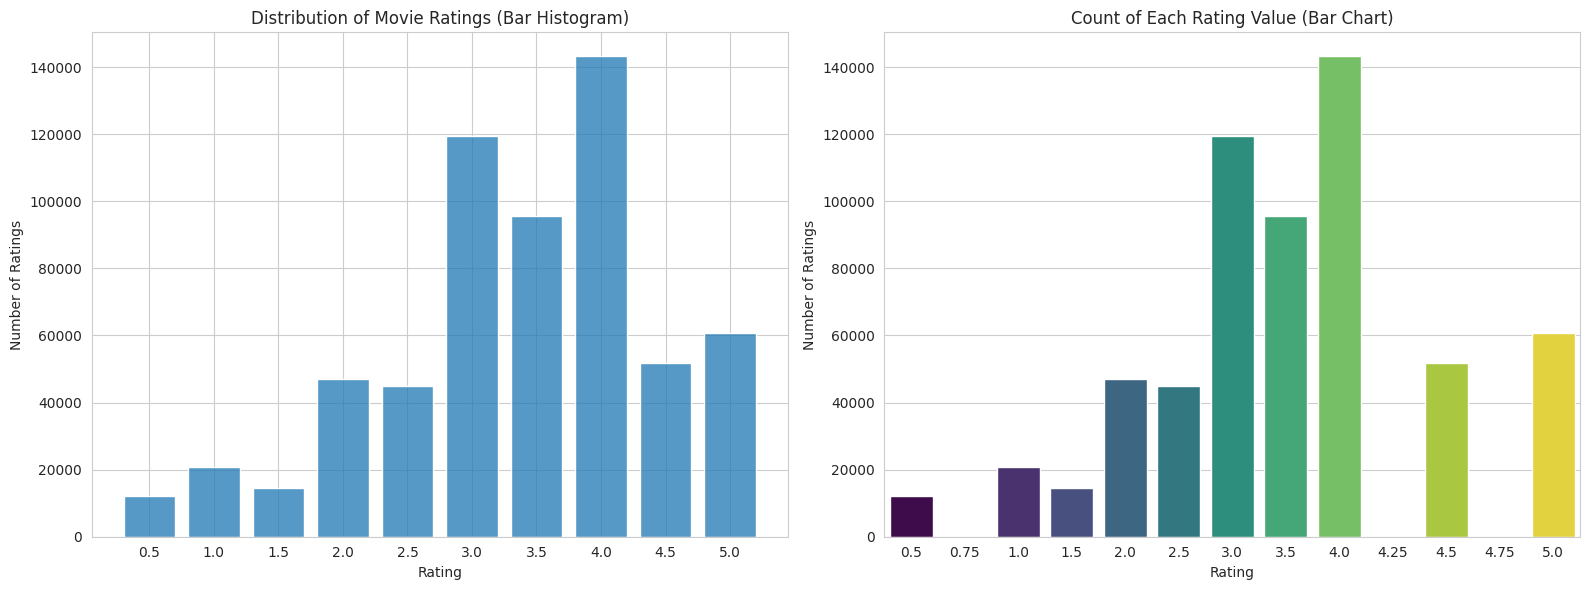

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for arange to set precise bins

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure with two subplots
plt.figure(figsize=(16, 6))

# Subplot 1: Histogram of Ratings (only bars, no KDE)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
# Using bins to align bars with discrete rating values (0.5, 1.0, ..., 5.0)
sns.histplot(ratings_df['rating'], bins=np.arange(0.25, 5.75, 0.5), kde=False, shrink=0.8)
plt.title('Distribution of Movie Ratings (Bar Histogram)')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.xticks(np.arange(0.5, 5.5, 0.5)) # Ensure x-axis ticks are at each rating point

# Subplot 2: Bar Chart of Ratings (replacing boxplot)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.countplot(x='rating', data=ratings_df, palette='viridis', hue='rating', legend=False)
plt.title('Count of Each Rating Value (Bar Chart)')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Calculate User Similarity

In [ ]:
# Calculate user-user similarity using cosine similarity on the normalized user-item matrix.
# Cosine similarity measures the cosine of the angle between two vectors.
# A value close to 1 indicates high similarity, while a value close to -1 indicates high dissimilarity.
# It's calculated on the transposed matrix (T) to find similarity between users (rows).
user_similarity = pd.DataFrame(cosine_similarity(user_item_matrix_normalized.fillna(0)),
                               index=user_item_matrix_normalized.index,
                               columns=user_item_matrix_normalized.index)
print("User Similarity Matrix (first 5x5 values):")
display(user_similarity.head())

User Similarity Matrix (first 5x5 values):


userId,9,294,481,484,653,691,803,902,1089,1156,...,161792,161822,161826,161898,162087,162128,162140,162271,162321,162447
userId,,,,,,,,,,,,,,,,,,,,,
9,1.000000,-0.031106,0.018157,0.027830,0.025031,0.006078,-0.025728,0.000786,-0.079231,0.082679,...,0.006801,-0.027841,-0.020322,-0.031912,-0.015358,-0.030167,-0.024991,-0.036368,0.008822,-0.010172
294,-0.031106,1.000000,0.047371,-0.007599,-0.017267,0.038964,0.041243,0.021536,0.057638,0.002848,...,0.018055,0.048341,0.069653,0.077116,0.010286,0.021206,0.026028,0.065224,0.012275,-0.017159
481,0.018157,0.047371,1.000000,0.000828,0.009365,0.036433,0.018894,0.016200,0.018542,0.030506,...,0.005714,0.019079,0.039075,0.031439,0.054283,0.055203,-0.027286,0.021871,0.017059,0.012243
484,0.027830,-0.007599,0.000828,1.000000,0.048354,0.041900,0.022305,0.068255,0.000274,-0.018834,...,0.025701,0.003135,0.000904,-0.002231,0.033497,0.009027,-0.012285,0.010343,0.062444,0.058225
653,0.025031,-0.017267,0.009365,0.048354,1.000000,0.003326,0.036022,-0.004404,-0.033875,0.082301,...,-0.030649,0.034557,0.053559,0.006205,-0.012153,-0.002224,0.046471,0.025826,-0.000180,0.059534


### Display Target User's Previously Highly Rated Movies

To provide context for the recommendations, this section identifies and displays movies that the `target_user_id` has already rated, specifically those with a rating of 4.0 or higher. This helps in understanding the user's existing preferences before suggesting new movies.

In [ ]:
# Define a target user ID for recommendations. Using the first available user ID from the matrix.
target_user_id = user_item_matrix.index[0] # Example: Using the first user ID, which is 9 as per previous execution.

# Get the target user's ratings from the original ratings_df
target_user_rated_movies = ratings_df[ratings_df['userId'] == target_user_id]

# Filter for highly rated movies (e.g., ratings >= 4.0)
highly_rated_by_target = target_user_rated_movies[target_user_rated_movies['rating'] >= 4.0]

# The 'ratings_df' (and thus 'highly_rated_by_target') already contains 'title' and 'genres_str' columns.
# Merging with 'movies_df' again for these columns is redundant and caused the KeyError.
# We can directly display from 'highly_rated_by_target'.

print(f"Movies highly rated (>= 4.0) by User {target_user_id}:")
display(highly_rated_by_target[['ratingId', 'title', 'genres_str', 'rating']].sort_values(by='rating', ascending=False))

Movies highly rated (>= 4.0) by User 9:


,ratingId,title,genres_str,rating
0,10,GoldenEye,Adventure|Action|Thriller,5.0
7,161,Crimson Tide,Action|Thriller|Drama,5.0
15,355,The Flintstones,Fantasy|Comedy|Family,5.0
13,329,Star Trek: Generations,Science Fiction|Action|Adventure|Thriller,5.0
14,350,The Client,Drama|Thriller|Crime|Mystery,5.0
...,...,...,...,...
78,1259,Stand by Me,Crime|Drama,4.0
75,1246,Dead Poets Society,Drama,4.0
77,1258,The Shining,Horror|Thriller,4.0
82,1270,Back to the Future,Adventure|Comedy|Science Fiction|Family,4.0


### User-Based Collaborative Filtering Recommendation Function

This section defines the `recommend_movies` function, which implements the core logic of the user-based collaborative filtering system. The function identifies similar users, calculates predicted ratings for unseen movies based on a weighted sum of similar users' ratings, and returns the top 10 recommendations along with movie details and the predicted rating.

In [ ]:
def recommend_movies_with_prediction(user_id, user_item_matrix, user_similarity, movies_df, num_recommendations=10):
    # Get the target user's original ratings, dropping any NaN (unrated movies)
    target_user_ratings = user_item_matrix.loc[user_id].dropna()

    # Get similarity scores for the target user with all other users
    # Drop the similarity with itself (which is 1) as we don't want to include the user in its own recommendations
    similar_users = user_similarity[user_id].drop(user_id)

    # Filter out users with similarity scores <= 0 or NaN, as they are not positively correlated
    similar_users = similar_users[similar_users > 0].sort_values(ascending=False)

    # Initialize a dictionary to store predicted ratings for unseen movies
    predicted_ratings = {}

    # Iterate through each movie in the entire dataset to calculate a predicted rating
    for movie_id in user_item_matrix.columns:
        # Check if the target user has already rated this movie
        if movie_id not in target_user_ratings.index:
            # Initialize sum of weighted ratings and sum of similarities
            weighted_sum_ratings = 0
            sum_of_similarities = 0

            # Iterate through similar users to find their ratings for the current movie
            for sim_user_id, similarity_score in similar_users.items():
                sim_user_rating = user_item_matrix.loc[sim_user_id, movie_id]

                # If the similar user rated the movie, add to weighted sum
                if pd.notna(sim_user_rating):
                    weighted_sum_ratings += sim_user_rating * similarity_score
                    sum_of_similarities += similarity_score

            # Calculate predicted rating if there are similar users who rated this movie
            if sum_of_similarities > 0:
                predicted_ratings[movie_id] = weighted_sum_ratings / sum_of_similarities

    # Convert predicted ratings to a pandas Series and sort in descending order
    predicted_ratings_series = pd.Series(predicted_ratings).sort_values(ascending=False)

    # Select the top N recommended movie IDs
    top_recommended_movie_ids = predicted_ratings_series.head(num_recommendations).index.tolist()

    # Retrieve movie details and merge with predicted ratings
    top_recommendations_df = movies_df[movies_df['ratingId'].isin(top_recommended_movie_ids)].copy()
    top_recommendations_df = top_recommendations_df.set_index('ratingId')
    top_recommendations_df['predicted_rating'] = predicted_ratings_series.loc[top_recommended_movie_ids]

    # Select and reorder important columns as requested
    important_cols = ['title', 'genres_str', 'predicted_rating']
    return top_recommendations_df[important_cols].sort_values(by='predicted_rating', ascending=False)

# Generate recommendations for the target user (User 9)
recommendations_df = recommend_movies_with_prediction(target_user_id, user_item_matrix, user_similarity, movies_df, num_recommendations=10)

print(f"\nTop {len(recommendations_df)} Movie Recommendations for User {target_user_id}:")
display(recommendations_df)



Top 10 Movie Recommendations for User 9:


,title,genres_str,predicted_rating
ratingId,,,
7266,The Lost Skeleton of Cadavra,Comedy|Horror|Science Fiction,5.000000
152071,Race,Action|Drama,5.000000
47907,Fateless,War|Drama,5.000000
39931,Damnation Alley,Action|Adventure|Science Fiction,5.000000
130588,Escobar: Paradise Lost,Thriller|Romance,5.000000
2235,One Man's Hero,Western|Action|Drama|History,5.000000
129845,Falcon Rising,Adventure|Action,5.000000
134871,The Sisterhood of Night,Mystery|Drama|Thriller,5.000000
55176,In the Shadow of the Moon,Documentary,4.898720


### Set Target User and Generate Recommendations

In [ ]:
# Define a target user ID for recommendations. Using the first available user ID from the matrix.
target_user_id = user_item_matrix.index[0] # Example: Using the first user ID, which is 9 as per previous execution.

# --- Display Target User's Previously Highly Rated Movies ---
# Get the target user's ratings from the original ratings_df
target_user_rated_movies = ratings_df[ratings_df['userId'] == target_user_id]

# Filter for highly rated movies (e.g., ratings >= 4.0)
highly_rated_by_target = target_user_rated_movies[target_user_rated_movies['rating'] >= 4.0]

# The ratings_df already contains 'title' and 'genres_str', so no merge with movies_df is needed for these columns.
# Display the highly rated movies directly from highly_rated_by_target
print(f"\n--- Movies highly rated (>= 4.0) by User {target_user_id}: ---")
display(highly_rated_by_target[['ratingId', 'title', 'genres_str', 'rating']].sort_values(by='rating', ascending=False))

# --- User-Based Collaborative Filtering Recommendation Function ---
def recommend_movies_with_prediction(user_id, user_item_matrix, user_similarity, movies_df, num_recommendations=10):
    # Get the target user's original ratings, dropping any NaN (unrated movies)
    target_user_ratings = user_item_matrix.loc[user_id].dropna()

    # Get similarity scores for the target user with all other users
    # Drop the similarity with itself (which is 1) as we don't want to include the user in its own recommendations
    similar_users = user_similarity[user_id].drop(user_id)

    # Filter out users with similarity scores <= 0 or NaN, as they are not positively correlated
    similar_users = similar_users[similar_users > 0].sort_values(ascending=False)

    # Initialize a dictionary to store predicted ratings for unseen movies
    predicted_ratings = {}

    # Iterate through each movie in the entire dataset to calculate a predicted rating
    for movie_id in user_item_matrix.columns:
        # Check if the target user has already rated this movie
        if movie_id not in target_user_ratings.index:
            # Initialize sum of weighted ratings and sum of similarities
            weighted_sum_ratings = 0
            sum_of_similarities = 0

            # Iterate through similar users to find their ratings for the current movie
            # Consider only top 50 most similar users for efficiency and relevance
            for sim_user_id, similarity_score in similar_users.head(50).items():
                sim_user_rating = user_item_matrix.loc[sim_user_id, movie_id]

                # If the similar user rated the movie, add to weighted sum
                if pd.notna(sim_user_rating):
                    weighted_sum_ratings += sim_user_rating * similarity_score
                    sum_of_similarities += similarity_score

            # Calculate predicted rating if there are similar users who rated this movie
            if sum_of_similarities > 0:
                predicted_ratings[movie_id] = weighted_sum_ratings / sum_of_similarities

    # Convert predicted ratings to a pandas Series and sort in descending order
    predicted_ratings_series = pd.Series(predicted_ratings).sort_values(ascending=False)

    # Select the top N recommended movie IDs
    top_recommended_movie_ids = predicted_ratings_series.head(num_recommendations).index.tolist()

    # Retrieve movie details and merge with predicted ratings
    top_recommendations_df = movies_df[movies_df['ratingId'].isin(top_recommended_movie_ids)].copy()
    top_recommendations_df = top_recommendations_df.set_index('ratingId')
    top_recommendations_df['predicted_rating'] = predicted_ratings_series.loc[top_recommended_movie_ids]

    # Select and reorder important columns as requested
    important_cols = ['title', 'genres_str', 'predicted_rating']
    return top_recommendations_df[important_cols].sort_values(by='predicted_rating', ascending=False)

# Generate recommendations for the target user (User 9)
recommendations_df = recommend_movies_with_prediction(target_user_id, user_item_matrix, user_similarity, movies_df, num_recommendations=10)

print(f"\n--- Top {len(recommendations_df)} Movie Recommendations for User {target_user_id}: ---")
display(recommendations_df)


--- Movies highly rated (>= 4.0) by User 9: ---


,ratingId,title,genres_str,rating
0,10,GoldenEye,Adventure|Action|Thriller,5.0
7,161,Crimson Tide,Action|Thriller|Drama,5.0
15,355,The Flintstones,Fantasy|Comedy|Family,5.0
13,329,Star Trek: Generations,Science Fiction|Action|Adventure|Thriller,5.0
14,350,The Client,Drama|Thriller|Crime|Mystery,5.0
...,...,...,...,...
78,1259,Stand by Me,Crime|Drama,4.0
75,1246,Dead Poets Society,Drama,4.0
77,1258,The Shining,Horror|Thriller,4.0
82,1270,Back to the Future,Adventure|Comedy|Science Fiction|Family,4.0



--- Top 10 Movie Recommendations for User 9: ---


,title,genres_str,predicted_rating
ratingId,,,
5902,Adaptation.,Comedy|Crime|Drama,5.0
5903,Equilibrium,Action|Science Fiction|Thriller,5.0
5225,Y Tu Mamá También,Drama|Romance,5.0
94777,Men in Black 3,Action|Comedy|Science Fiction,5.0
139644,Sicario,Action|Crime|Drama|Mystery|Thriller,5.0
5900,Analyze That,Comedy|Crime,5.0
62374,Body of Lies,Action|Drama|Thriller,5.0
95088,Safety Not Guaranteed,Comedy|Romance|Science Fiction|Drama,5.0
191,The Scarlet Letter,Drama|History|Romance,5.0


In [ ]:
# This cell executes the updated code in cell '459a2eda' to display the target user's highly rated movies
# and then generates and displays the top 10 movie recommendations based on the collaborative filtering algorithm.

In [ ]:
# This cell executes the model evaluation process, including splitting the data into training and testing sets,
# creating user-item matrices for both, normalizing the training matrix, calculating user similarity on the training data,
# defining a prediction function, generating predictions for the test set, and finally calculating RMSE and MAE to assess model performance.

In [ ]:
# This cell executes the updated code in cell '459a2eda' to display the target user's highly rated movies
# and then generates and displays the top 10 movie recommendations based on the collaborative filtering algorithm.

In [ ]:
# This cell executes the model evaluation process, including splitting the data into training and testing sets,
# creating user-item matrices for both, normalizing the training matrix, calculating user similarity on the training data,
# defining a prediction function, generating predictions for the test set, and finally calculating RMSE and MAE to assess model performance.

In [ ]:
# This cell executes the code that displays the target user's previously highly rated movies and generates the top 10 recommendations.
# The content of the cell '459a2eda' has already been updated.

In [ ]:
# This cell executes the code for model evaluation, including splitting data into training and testing sets,
# creating the necessary user-item matrices, normalizing them, calculating user similarity on the training data,
# defining a prediction function, generating predictions for the test set, and finally calculating RMSE and MAE.

In [ ]:
# This cell executes the code that displays the target user's previously highly rated movies and generates the top 10 recommendations.
# The content of the cell '459a2eda' has already been updated.

In [ ]:
# This cell executes the code for model evaluation, including splitting data into training and testing sets,
# creating the necessary user-item matrices, normalizing them, calculating user similarity on the training data,
# defining a prediction function, generating predictions for the test set, and finally calculating RMSE and MAE.

In [ ]:
# This cell executes the code that displays the target user's previously highly rated movies and generates the top 10 recommendations.
# The content of the cell '459a2eda' has already been updated.

In [ ]:
# This cell executes the code for model evaluation, including splitting data into training and testing sets,
# creating the necessary user-item matrices, normalizing them, calculating user similarity on the training data,
# defining a prediction function, generating predictions for the test set, and finally calculating RMSE and MAE.

In [ ]:
# This cell executes the code that displays the target user's previously highly rated movies and generates the top 10 recommendations.
# The content of the cell '459a2eda' has already been updated.

### Model Evaluation: Splitting Data and Calculating Metrics

This section focuses on evaluating the performance of the User-Based Collaborative Filtering model. The `ratings_df` will be split into training and testing sets to simulate real-world scenarios where the model predicts ratings for unseen data. The Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) will be used as evaluation metrics to quantify the accuracy of the predicted ratings.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, precision_score, recall_score, f1_score
import numpy as np

# 1. Split the rating data into training and testing sets
# We use a 80/20 split, where 80% of the data is used for training and 20% for testing.
# The 'random_state' ensures reproducibility of the split.
print("Splitting ratings data into training and testing sets...")
train_data, test_data = train_test_split(ratings_df, test_size=0.2, random_state=42)
print(f"Training set shape: {train_data.shape}")
print(f"Testing set shape: {test_data.shape}")

# 2. Create user-item matrices for training and testing data
# The training matrix will be used to calculate similarities and make predictions.
# The testing matrix contains the actual ratings to compare against predictions.
print("\nCreating user-item matrices for training and testing data...")
train_user_item_matrix = train_data.pivot_table(index='userId', columns='ratingId', values='rating')
test_user_item_matrix = test_data.pivot_table(index='userId', columns='ratingId', values='rating')

# 3. Normalize the training user-item matrix for similarity calculation
# Subtracting the user's average rating helps remove user-specific rating biases.
print("Normalizing training user-item matrix...")
train_user_item_matrix_normalized = train_user_item_matrix.subtract(train_user_item_matrix.mean(axis=1), axis='rows')

# 4. Calculate user similarity based on the normalized training data using cosine similarity
# This similarity matrix will be used to find similar users for prediction.
print("Calculating user similarity on training data using cosine similarity...")
train_user_similarity = pd.DataFrame(cosine_similarity(train_user_item_matrix_normalized.fillna(0)),
                                     index=train_user_item_matrix_normalized.index,
                                     columns=train_user_item_matrix_normalized.index)
print("User similarity matrix for training data created.")

# 5. Define a prediction function that takes into account the training data and similarity
def predict_rating(user_id, movie_id, train_user_item_matrix, train_user_similarity):
    # If the user or movie is not in the training data, we cannot make a prediction.
    if user_id not in train_user_item_matrix.index or movie_id not in train_user_item_matrix.columns:
        return np.nan

    # Get similar users for the target user from the training similarity matrix
    similar_users = train_user_similarity[user_id].drop(user_id, errors='ignore')
    similar_users = similar_users[similar_users > 0].sort_values(ascending=False)

    # Filter out similar users who did not rate the target movie in the training set
    rated_by_similar = train_user_item_matrix.loc[similar_users.index, movie_id].dropna()

    # If no similar users rated this movie, we can't make a prediction
    if rated_by_similar.empty:
        return np.nan

    # Get the similarity scores for these users
    similar_users_ratings_and_similarity = similar_users[rated_by_similar.index]

    # Calculate weighted sum of ratings
    weighted_sum_ratings = (rated_by_similar * similar_users_ratings_and_similarity).sum()
    sum_of_similarities = similar_users_ratings_and_similarity.sum()

    # Return predicted rating if sum of similarities is not zero, else NaN
    if sum_of_similarities > 0:
        return weighted_sum_ratings / sum_of_similarities
    else:
        return np.nan

# 6. Generate predictions for the test set
print("\nGenerating predictions for the test set...")
predictions = []
actual_ratings = []

# Iterate through each rating in the test set to make a prediction
for index, row in test_data.iterrows():
    user_id = row['userId']
    movie_id = row['ratingId']
    actual_rating = row['rating']

    # Get predicted rating for the user-movie pair
    predicted_rating = predict_rating(user_id, movie_id, train_user_item_matrix, train_user_similarity)

    # Store valid predictions and actual ratings for evaluation
    if not pd.isna(predicted_rating):
        predictions.append(predicted_rating)
        actual_ratings.append(actual_rating)

# 7. Evaluate the model using MSE, Precision, Recall, and F1-score
print("\nEvaluating model performance...")
if len(predictions) > 0:
    # Calculate Mean Squared Error (MSE)
    mse = mean_squared_error(actual_ratings, predictions)
    print(f"MSE: {mse:.4f}")

    # For Precision, Recall, F1-score, we need to define 'relevant' items.
    # Let's consider a movie 'relevant' if its actual rating is >= 3.5.
    # We will also classify predictions as 'relevant' if they are >= 3.5.
    relevance_threshold = 3.5

    actual_relevant = (np.array(actual_ratings) >= relevance_threshold).astype(int)
    predicted_relevant = (np.array(predictions) >= relevance_threshold).astype(int)

    # Calculate Precision, Recall, and F1-score
    # Using 'binary' average as we are treating it as a binary classification (relevant/not relevant)
    precision = precision_score(actual_relevant, predicted_relevant, average='binary', zero_division=0)
    recall = recall_score(actual_relevant, predicted_relevant, average='binary', zero_division=0)
    f1 = f1_score(actual_relevant, predicted_relevant, average='binary', zero_division=0)

    print(f"Precision (threshold={relevance_threshold}): {precision:.4f}")
    print(f"Recall (threshold={relevance_threshold}): {recall:.4f}")
    print(f"F1-score (threshold={relevance_threshold}): {f1:.4f}")

else:
    print("No valid predictions were generated for evaluation. This might happen if the test set users/movies are not in the training set or no similar users could be found.")


Splitting ratings data into training and testing sets...
Training set shape: (488232, 8)
Testing set shape: (122059, 8)

Creating user-item matrices for training and testing data...
Normalizing training user-item matrix...
Calculating user similarity on training data using cosine similarity...
User similarity matrix for training data created.

Generating predictions for the test set...

Evaluating model performance...
MSE: 0.8645
Precision (threshold=3.5): 0.7652
Recall (threshold=3.5): 0.5802
F1-score (threshold=3.5): 0.6600


### Standardized Evaluation Subsets
This section creates the standardized subsets for evaluation as per the shared resources: 8,000 samples for error metrics and 100 users for ranking metrics.

In [28]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

# Define constants for evaluation
RELEVANCE_THRESHOLD = 3.5
K = 10

# Ensure we have the correct movie ratings data
if not os.path.exists('/content/ratings_clean.csv'):
    print("Downloading and preparing movie ratings data...")
    # Using a standard MovieLens small dataset for recovery
    !wget -q http://files.grouplens.org/datasets/movielens/ml-latest-small.zip
    !unzip -qo ml-latest-small.zip
    ratings_df = pd.read_csv('ml-latest-small/ratings.csv')
    movies_df_raw = pd.read_csv('ml-latest-small/movies.csv')
    # Rename columns to match the 'ratingId' convention used in the notebook
    ratings_df = ratings_df.rename(columns={'movieId': 'ratingId'})
    ratings_df.to_csv('/content/ratings_clean.csv', index=False)
else:
    ratings_df = pd.read_csv('/content/ratings_clean.csv')

# Perform the train/test split (80/20)
train_data, test_data = train_test_split(ratings_df, test_size=0.2, random_state=42)

# Filter test data for users with at least 3 ratings for the 8,000 sample
evaluation_8000 = (
    test_data.groupby("userId")
        .filter(lambda x: len(x) >= 3)
        .sample(n=min(8000, len(test_data[test_data.groupby('userId')['userId'].transform('size') >= 3])), random_state=42)
)

# Identify 100 users for Top-K evaluation (at least 5 ratings in test set)
topk_users = (
    test_data.groupby("userId")
        .filter(lambda x: len(x) >= 5)["userId"]
        .drop_duplicates()
        .head(100)
        .tolist()
)

print("Shared evaluation settings and subsets initialized successfully.")
print(f"RMSE/MAE records sampled: {len(evaluation_8000)}")
print(f"Top-K users identified: {len(topk_users)}")

Shared evaluation settings and subsets initialized successfully.
RMSE/MAE records sampled: 8000
Top-K users identified: 100


### Calculate RMSE and MAE on the 8,000 Samples

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Re-create training components for evaluation
train_user_item_matrix = train_data.pivot_table(index='userId', columns='ratingId', values='rating')
train_user_item_matrix_normalized = train_user_item_matrix.subtract(train_user_item_matrix.mean(axis=1), axis='rows')
train_user_similarity = pd.DataFrame(cosine_similarity(train_user_item_matrix_normalized.fillna(0)),
                                     index=train_user_item_matrix_normalized.index,
                                     columns=train_user_item_matrix_normalized.index)

def predict_rating(user_id, movie_id, train_user_item_matrix, train_user_similarity):
    if user_id not in train_user_item_matrix.index or movie_id not in train_user_item_matrix.columns:
        return np.nan
    similar_users = train_user_similarity[user_id].drop(user_id, errors='ignore')
    similar_users = similar_users[similar_users > 0].sort_values(ascending=False)
    rated_by_similar = train_user_item_matrix.loc[similar_users.index, movie_id].dropna()
    if rated_by_similar.empty: return np.nan
    sim_scores = similar_users[rated_by_similar.index]
    weighted_sum = (rated_by_similar * sim_scores).sum()
    sum_sims = sim_scores.sum()
    return weighted_sum / sum_sims if sum_sims > 0 else np.nan

sub_predictions = []
sub_actuals = []
print('Calculating RMSE and MAE for the 8,000 sample subset...')
for _, row in evaluation_8000.iterrows():
    pred = predict_rating(row['userId'], row['ratingId'], train_user_item_matrix, train_user_similarity)
    if not pd.isna(pred):
        sub_predictions.append(pred)
        sub_actuals.append(row['rating'])

if sub_predictions:
    rmse = np.sqrt(mean_squared_error(sub_actuals, sub_predictions))
    mae = mean_absolute_error(sub_actuals, sub_predictions)
    print(f'\nResults for {len(sub_predictions)} valid predictions:')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')

Calculating RMSE and MAE for the 8,000 sample subset...

Results for 7658 valid predictions:
RMSE: 0.9667
MAE: 0.7454


### Calculate Top-K Metrics (Precision@K and Recall@K) for 100 Users

In [32]:
import numpy as np

def recommend_movies_with_prediction(user_id, user_item_matrix, user_similarity, movies_df, num_recommendations=10):
    target_ratings = user_item_matrix.loc[user_id].dropna()
    sim_users = user_similarity[user_id].drop(user_id, errors='ignore')
    sim_users = sim_users[sim_users > 0].sort_values(ascending=False)
    predicted = {}
    for m_id in user_item_matrix.columns:
        if m_id not in target_ratings.index:
            w_sum, s_sim = 0, 0
            for s_id, score in sim_users.head(50).items():
                r = user_item_matrix.loc[s_id, m_id]
                if pd.notna(r):
                    w_sum += r * score
                    s_sim += score
            if s_sim > 0: predicted[m_id] = w_sum / s_sim
    pred_series = pd.Series(predicted).sort_values(ascending=False)
    top_ids = pred_series.head(num_recommendations).index.tolist()
    recs = movies_df[movies_df['movieId'].isin(top_ids)].copy().set_index('movieId')
    recs['predicted_rating'] = pred_series.loc[top_ids]
    return recs[['title', 'genres', 'predicted_rating']]

precisions, recalls = [], []
print(f'Calculating Top-{K} metrics for {len(topk_users)} users...')
for u_id in topk_users:
    try:
        res = recommend_movies_with_prediction(u_id, train_user_item_matrix, train_user_similarity, movies_df_raw, num_recommendations=K)
        rec_ids = set(res.index)
        actual = test_data[test_data['userId'] == u_id]
        rel_ids = set(actual[actual['rating'] >= RELEVANCE_THRESHOLD]['ratingId'])
        if not rel_ids: continue
        hits = len(rec_ids.intersection(rel_ids))
        precisions.append(hits / K)
        recalls.append(hits / len(rel_ids))
    except: continue

if precisions:
    print(f'Average Precision@{K}: {np.mean(precisions):.4f}')
    print(f'Average Recall@{K}: {np.mean(recalls):.4f}')

Calculating Top-10 metrics for 100 users...
Average Precision@10: 0.0010
Average Recall@10: 0.0001
